# Lab 9: Quantun Computing - Rabi Oscillations

Nombre estudiante:

c.c:

## Exercise 1: $NH_3$ molecule

An example of the quantum oscillations in two-level systems may be rather unexpected; for example, the ammonium molecule 

![NH3](../Sesiones/QC/figures/NH3.png)
![NH3](NH3.png)

 It has two symmetric states that differ by the inversion of the nitrogen atom relative to the plane of the three hydrogen atoms, which are weakly coupled due to quantum-mechanical tunneling of the nitrogen atom through the plane of the hydrogen atoms. Since for this particular molecule, in the absence of external fields, the level splitting $\Delta E$ corresponds to an experimentally convenient frequency $\Omega/2\pi\approx$ 24.79 GHz.

 1. Supose a detuning frequency $\Omega_R/2$.
 2. Compute the Rabi frequency for NH3 molecule in Hz and do a plot of the Rabi oscillation. Supose that the initial state is $\ket{2}$.
 
 [see](https://phys.libretexts.org/Bookshelves/Quantum_Mechanics/Essential_Graduate_Physics_-_Quantum_Mechanics_(Likharev)/05%3A_Some_Exactly_Solvable_Problems/5.01%3A_Two-level_Systems)

## Exercise: Bell state

1. Creates a quantum circuit for two qubits, consisting of the quantum gates needed to create a `Bell state`  (two entangled qubits). The quantum circuit then terminates with quantum measurements, extracting one bit from each qubit.

2. Add a third qubit by changing to QuantumCircuit(3), and add a second CX gate with qc.cx(1,2). The measurements should then change to 000 and 111, which means all three of these qubits have been entangled.

3. See your results shift by adding qc.x(1) to the end of the circuit.

Frecuencia Rabi de drive (Hz): 1.000000e+06
Detuning (Hz): 5.000000e+05
Frecuencia Rabi generalizada (Hz): 1.118034e+06


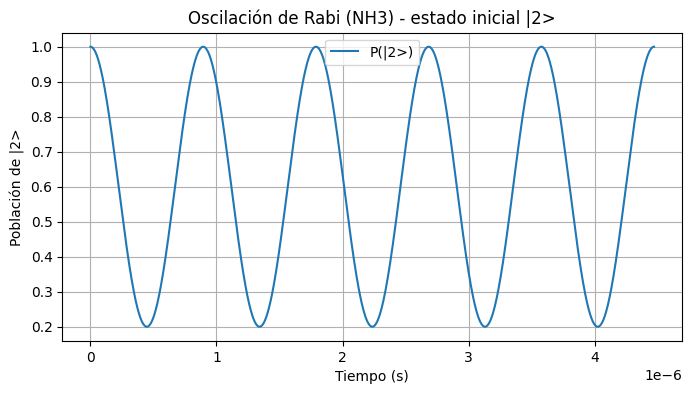

In [1]:
# Ejercicio 1
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# Datos físicos: el desdoblamiento de niveles corresponde a f0 = 24.79 GHz
f0 = 24.79e9  # Hz (frecuencia de transición)
omega0 = 2*pi*f0  # rad/s (frecuencia angular de la transición)

# Parámetros del campo 
drive_rabi_freq_hz = 1e6  # 1 MHz
detuning_hz = 0.5e6       # detuning 

# (rad/s)
Omega_0 = 2*pi*drive_rabi_freq_hz
Delta = 2*pi*detuning_hz

# Frecuencia Rabi generalizada (angular)
Omega_R = np.sqrt(Omega_0**2 + Delta**2)

Omega_R_hz = Omega_R/(2*pi)
print(f"Frecuencia Rabi de drive (Hz): {drive_rabi_freq_hz:.6e}")
print(f"Detuning (Hz): {detuning_hz:.6e}")
print(f"Frecuencia Rabi generalizada (Hz): {Omega_R_hz:.6e}")

# Evolución de poblaciones: asumimos estado inicial |2> (estado excitado).
# Usando las fórmulas estándar para un sistema de dos niveles (frecuencias angulares):
# P_excited(t) = 1 - (Omega_0^2 / Omega_R^2) * sin^2(Omega_R * t / 2)
t = np.linspace(0, 5/(Omega_R_hz if Omega_R_hz>0 else 1e6), 1000)  # abarcar varios periodos de Rabi
P_excited = 1 - (Omega_0**2 / Omega_R**2) * np.sin(0.5 * Omega_R * t)**2

plt.figure(figsize=(8,4))
plt.plot(t, P_excited, label="P(|2>)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Población de |2>")
plt.title("Oscilación de Rabi (NH3) - estado inicial |2>")
plt.grid(True)
plt.legend()
plt.show()

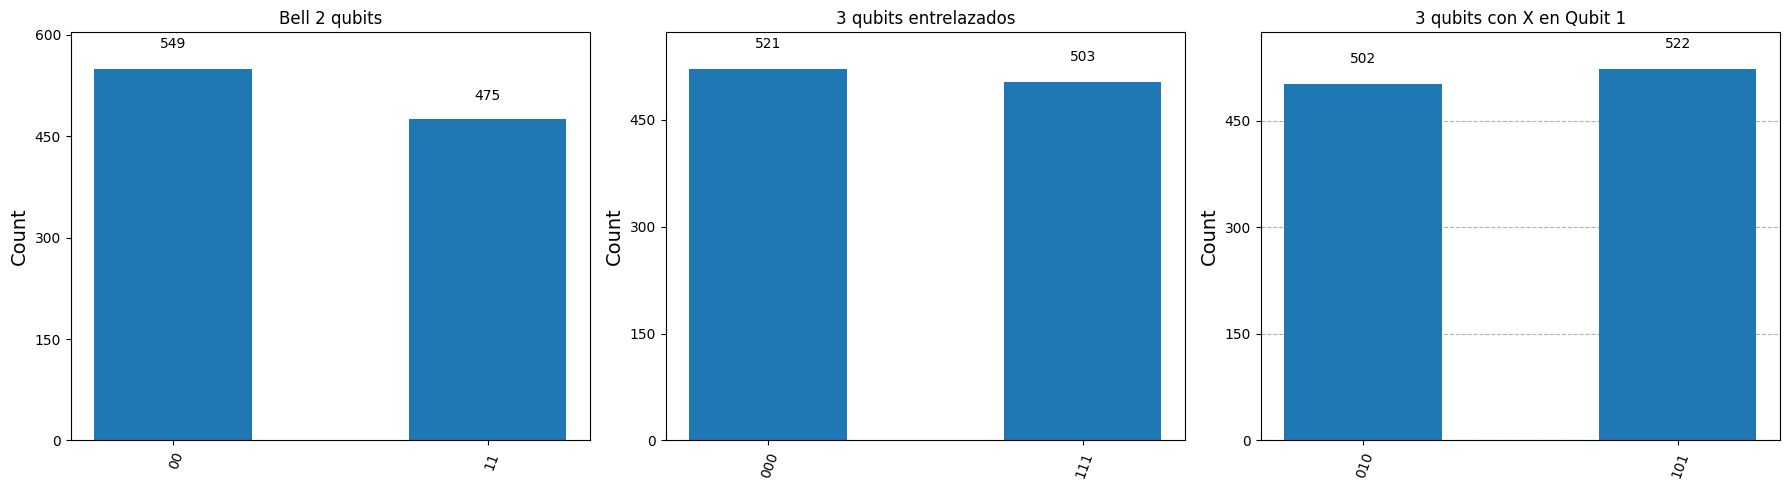

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Definir el simulador moderno de Qiskit Aer
backend = AerSimulator()

# ==========================================
# 1) Estado Bell de dos qubits
# ==========================================
qc2 = QuantumCircuit(2, 2)
qc2.h(0)
qc2.cx(0, 1)
qc2.measure([0, 1], [0, 1])

qc2_compiled = transpile(qc2, backend)
job = backend.run(qc2_compiled, shots=1024)
counts2 = job.result().get_counts()

# ==========================================
# 2) Estado GHZ-like de tres qubits
# ==========================================
qc3 = QuantumCircuit(3, 3)
qc3.h(0)
qc3.cx(0, 1)
qc3.cx(1, 2)
qc3.measure([0, 1, 2], [0, 1, 2])

qc3_compiled = transpile(qc3, backend)
job3 = backend.run(qc3_compiled, shots=1024)
counts3 = job3.result().get_counts()

# ==========================================
# 3) Añadir qc.x(1) al final y volver a ejecutar
# ==========================================
qc3_mod = QuantumCircuit(3, 3)
qc3_mod.h(0)
qc3_mod.cx(0, 1)
qc3_mod.cx(1, 2)
qc3_mod.x(1)
qc3_mod.measure([0, 1, 2], [0, 1, 2])

qc3_mod_compiled = transpile(qc3_mod, backend)
job3m = backend.run(qc3_mod_compiled, shots=1024)
counts3m = job3m.result().get_counts()

# ==========================================
# Creación de la figura con Subplots (1x3)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma 1 (Bell)
plot_histogram(counts2, ax=axes[0])
axes[0].set_title("Bell 2 qubits")

# Histograma 2 (GHZ)
plot_histogram(counts3, ax=axes[1])
axes[1].set_title("3 qubits entrelazados")

# Histograma 3 (GHZ Modificado con X)
plot_histogram(counts3m, ax=axes[2])
axes[2].set_title("3 qubits con X en Qubit 1")

# Ajustar diseño y mostrar
plt.tight_layout()
plt.show()



In [ ]:
Nota: 4.7. no están lo circuitos.... muy bien por acercarse a estos temas. 

SyntaxError: invalid syntax (1135234863.py, line 1)